<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 8 - Model Selection and Cross validation</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

## Objective
In this TD, you will learn about model selection.

In [1]:
import numpy as np
import pandas as pd
from tqdm import trange

from bandit_task import ReversalBanditTask
from rl_models import RLModel, BiasRLModel, RepeatRLModel

In [2]:
%reload_ext autoreload
%autoreload 2

## The task
We will use behavioral data generated with the following `ReversalBanditTask`. It is displayed here so that you understand what we are working with, but since we work with experimental data, we will not need to perform model simulation in this TD.

⚙️ Execute this cell to visualize the task

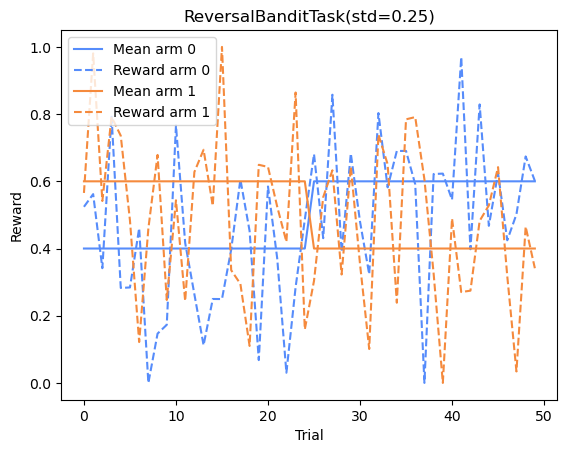

In [3]:
np.random.seed(42)
ReversalBanditTask(0.4, 0.6, 0.25, 50).plot()


## Dataset
### Load Participant Data
We will work with a dataset similar to the ones you might work with when you run a study with participants. The data is in `experimental_data.csv`. Each line corresponds to a separate **trial**. The columns are the following:
- `subject_id`: the ID of the subject (string)
- `block`: the block number (starting from 0)
- `trial`: the trial number (starting from 0)
- `action`: the action taken by the subject (0 or 1)
- `reward`: the reward received by the subject

📝 Load the data and show the first 5 lines

In [4]:
# Solution
data = pd.read_csv('experimental_data.csv')
data.head()

,subject_id,block,trial,action,reward
0,SUBJ01,0,0,1,0.565434
1,SUBJ01,0,1,0,0.561922
2,SUBJ01,0,2,0,0.341462
3,SUBJ01,0,3,1,0.791859
4,SUBJ01,0,4,1,0.735640


### Explore the data
In this section, we will explore the data to understand its structure and the number of trials, blocks, and subjects. This will involve a more advanced usage of the Pandas library. Take this opportunity to practice your Pandas skills, and ask around to get some tips if needed. Make sure you don't spend more than 15 minutes on this section.

📝 Find how many subjects participated in the experiment

In [5]:
# Solution
n_subj = data.subject_id.nunique()
n_subj

3

📝 How many blocks were in the experiment?

In [6]:
# Solution
n_blocks = data.block.nunique()
n_blocks

5

📝 How many trials per block?

In [7]:
# Solution
n_trials = data['trial'].nunique()
n_trials

100

### Data processing
The trial-by-trial tabular format might be useful to save the data, but to feed it to RL models, we will need to transform it into a more compact format.

We will extract the data for each subject and stack the blocks together. The resulting data will be, for each subject, two 2D arrays of shape `(n_blocks, n_trials)`, one for actions and one for rewards.

Let's try for one example.

📝Create a `subj_1_actions` array that contains the actions of subject 1 for all blocks. The shape of the array should be (5, 100) (5 blocks, 100 trials per block).

In [8]:
# Solution
subj_1_actions = data[data['subject_id'] == 'SUBJ01']['action'].values.reshape(n_blocks, n_trials)
subj_1_actions.shape

(5, 100)

Now let's make a helper function to extract the data for a given subject.

📝 Complete the `extract_subject_data` funciton. It should take the subject ID as an argument and return the actions and rewards as 2D arrays of shape (n_blocks, n_trials).

In [9]:
# Solution (simple)
def extract_subject_data_easy(subj_id, data=data):
    subj_data = data[data['subject_id'] == subj_id]
    actions = subj_data['action'].values.reshape(n_blocks, n_trials)
    rewards = subj_data['reward'].values.reshape(n_blocks, n_trials)
    return actions, rewards

In [10]:
# Solution (more robust)
def extract_subject_data(subj_id: int, data=data):
    subj_data = data[data['subject_id'] == subj_id]
    block_actions = []
    block_rewards = []
    for block in range(n_blocks):
        block_actions.append(subj_data[subj_data['block'] == block]['action'])
        block_rewards.append(subj_data[subj_data['block'] == block]['reward'])
    actions = np.stack(block_actions, axis=0)
    rewards = np.stack(block_rewards, axis=0)
    return actions, rewards

⚙️ Verify that the function works as expected by extracting the data for subject `SUBJ01` and checking the shape of the arrays. They should both have the shape (n_blocks, n_trials).

In [11]:
actions_subj_1, rewards_subj_1 = extract_subject_data('SUBJ01')
actions_subj_1.shape, rewards_subj_1.shape

((5, 100), (5, 100))

## Define the models
We will compare the three variations of the Reinforcement Learning model with which we worked last time. They are already implemented in the `rl_models.py` file and have been imported in this notebook. They were adapted to be able to process **blocked data**.

⚙️Run the cell below:
- The `candidate_models` list below contains the three model classes that will be involved in the model recovery. We will reuse this list throughout the notebook.
- The `model_names` list contains the model names in string format in the same order. It will be used later to display the results of the model recovery in a more readable way.

In [12]:
candidate_models = [RLModel, BiasRLModel, RepeatRLModel]

model_names = [model.__name__ for model in candidate_models]
model_names

['RLModel', 'BiasRLModel', 'RepeatRLModel']

### Cross Validation
There are a many steps involved in cross validation. As usual, we will start by understanding each step separately, then we will put them together in a loop.
#### A) Step by step

##### 1. Extract data per subject and block
📝 Extract the actions and rewards from subject `SUBJ01`

In [13]:
# Solution
actions_s1, rewards_s1 = extract_subject_data('SUBJ01')

📝 Extract blocks 0, 1 and 2 separately (for subject `SUBJ01`)

In [14]:
# Solution
actions_s1_b0 = actions_s1[0].reshape(1, -1)
rewards_s1_b0 = rewards_s1[0].reshape(1, -1)

actions_s1_b1 = actions_s1[1].reshape(1, -1)
rewards_s1_b1 = rewards_s1[1].reshape(1, -1)

actions_s1_b2 = actions_s1[2].reshape(1, -1)
rewards_s1_b2 = rewards_s1[2].reshape(1, -1)

⚠️ Make sure that your actions and rewards remain 2D arrays of shape (n_blocks, n_trials), even if you only have one block. You can use the `reshape` method to do this.

In [15]:
actions_s1_b1.shape, rewards_s1_b1.shape, actions_s1_b2.shape, rewards_s1_b2.shape

((1, 100), (1, 100), (1, 100), (1, 100))

##### 2. Fit models
📝 Fit a separate `RLModel` to each block's data.

In [16]:
# Solution
model_s1_b0 = RLModel.fit(actions_s1_b0, rewards_s1_b0, verbose=False)
model_s1_b1 = RLModel.fit(actions_s1_b1, rewards_s1_b1, verbose=False)
model_s1_b2 = RLModel.fit(actions_s1_b2, rewards_s1_b2, verbose=False)

##### 3. Validation
Validation means computing the log likelihood of the model on a block that was NOT used for fitting (i.e. **unseen data**). The log likelihood is a measure of how well the model explains the data. The higher the log likelihood, the better the model fits the data. We will compare the likelihoods of a model on its fitting data and on unseen data.

📝 Validate all three models on the data from block 0.

In [17]:
# Solution
ll_model_b0_val_b0 = model_s1_b0.log_likelihood(actions_s1_b0, rewards_s1_b0)
ll_model_b1_val_b0 = model_s1_b1.log_likelihood(actions_s1_b0, rewards_s1_b0)
ll_model_b2_val_b0 = model_s1_b2.log_likelihood(actions_s1_b0, rewards_s1_b0)

💭 Which model has the best likelihood on block 0's data? Is it surprising?

In [18]:
# Solution
pd.Series({
    'Model fit on block 0': ll_model_b0_val_b0,
    'Model fit on block 1': ll_model_b1_val_b0,
    'Model fit on block 2': ll_model_b2_val_b0,
}, name='likelihood on block 0').sort_values(ascending=False)

Model fit on block 0   -41.158660
Model fit on block 2   -41.690437
Model fit on block 1   -42.708546
Name: likelihood on block 0, dtype: float64

#### B) Fitting on 4 blocks and validating on 1 block
What we usually do when we have many blocks is that we fit the data to a large portion of the blocks, and keep a small portion for validation. This provides a better estimate of the fit. Here, we will use **4 blocks for fitting** and **1 block for validation**.

📝 Extract again the data from subject 1

In [19]:
actions_s1, rewards_s1 = extract_subject_data("SUBJ01")

📝 Extract the fitting and validation data. For the exercise, keep block 4 for validation.
> - You can slice numpy arrays to select rows, and use the np.delete() function to remove a specific row from an array
> - Again, check that your arrays remain 2D, even if there is just one block

In [20]:
# Solution
fit_actions = np.delete(actions_s1, 4, axis=0)
fit_rewards = np.delete(rewards_s1, 4, axis=0)

val_actions = actions_s1[4].reshape(1, -1)
val_rewards = rewards_s1[4].reshape(1, -1)

⚙️ Check your array dimensions

In [21]:
fit_actions.shape, fit_rewards.shape, val_actions.shape, val_rewards.shape

((4, 100), (4, 100), (1, 100), (1, 100))

📝 Fit an `RLModel` to the fitting data

In [22]:
# Solution
fitted_model = RLModel.fit(fit_actions, fit_rewards, verbose=False)

📝 Compute the log likelihood on the validation data

In [23]:
# Solution
log_likelihood = fitted_model.log_likelihood(val_actions, val_rewards)
log_likelihood

np.float64(-22.649131428827612)

#### Full cross validation loop
Now let's put all this code in a loop that will run the validation routine **5 times**. At each time, a different block is used for the validation, and the rest is used for fitting.

📝 Fill the `cross_validation` function

In [24]:
# Solution
def cross_validation(model_class, actions, rewards, n_blocks=5):
    cv_log_likelihood = 0
    for val_block in trange(n_blocks, desc=f'Cross-validation {model_class.__name__}', unit='block'):
        # Extract fitting data and validation data
        fit_actions = np.delete(actions, val_block, axis=0)
        fit_rewards = np.delete(rewards, val_block, axis=0)

        val_actions = actions[val_block, :].reshape(1, -1)
        val_rewards = rewards[val_block, :].reshape(1, -1)

        fitted_model = model_class.fit(fit_actions, fit_rewards, verbose=False)

        # Compute validation log likelihood
        log_likelihood = fitted_model.log_likelihood(val_actions, val_rewards)
        cv_log_likelihood += log_likelihood

    return cv_log_likelihood

In [25]:
cross_validation(RLModel, *extract_subject_data("SUBJ01"))

Cross-validation RLModel: 100%|██████████| 5/5 [00:08<00:00,  1.79s/block]


np.float64(-162.12068029376826)

# Model Selection

### Selection Criteria
Let's reuse the criteria from last TD to compare with Cross Validation.

#### Log likelihood
📝 Complete the `loglikelihood_evaluation` function. It is slightly different from last TD's because now it takes a model class (`RLModel`, `BiasRLModel` or `RepeatRLModlel`), which you need fit to the data (`actions` `rewards`) before computing the log likelihood. A

> ＊As we have seen, log likelihood is not an appropriate criterion to compare different models, but we will use it for comparison.
> 
> ⚠️ Make sure it returns a float, not an array!

In [26]:
# Solution
def loglikelihood_evaluation(model_class, actions, rewards) -> float:
    fitted_model = model_class.fit(actions, rewards, verbose=False)
    ll = fitted_model.log_likelihood(actions, rewards)
    return ll

#### Bayesian Information Criterion (BIC)
$$
\text{BIC} = -2 \cdot \log L + k \cdot \log n
$$
Where:
- $L$ is the likelihood of the behavior given the fitted model
- $k$ is the number of parameters in the model
- $n$ is the number of data points

📝 Complete the `bic_evaluation` function.

In [27]:
# Solution
def bic_evaluation(model_class, actions, rewards) -> float:
    fitted_model = model_class.fit(actions, rewards, verbose=False)
    ll = fitted_model.log_likelihood(actions, rewards)

    k = model_class.n_params
    n = actions.size    # Watch out for this one: n = n_trials * n_blocks
    bic = -2 * ll + k * np.log(n)
    return bic

### Akaike Information Criterion (AIC)
$$
\text{AIC} = -2 \cdot \log L + 2k
$$
Where:
- $L$ is the likelihood of the behavior given the fitted model
- $k$ is the number of parameters in the model

📝 Complete the `aic_evaluation` function.

In [28]:
# Solution
def aic_evaluation(model_class, actions, rewards) -> float:
    fitted_model = model_class.fit(actions, rewards, verbose=False)
    ll = fitted_model.log_likelihood(actions, rewards)

    k = model_class.n_params
    aic = -2 * ll + 2 * k
    return aic

### Model Selection on Subject 1
Now let's run model selection to find what model best explains the behavior of Subject `SUBJ01`.

📝 Complete the `evaluate_models` function. 
- It sould take a list of model classes to evaluate
- It should take in the actions and rewards of a specific subject (as they are produced by the `extract_subject_data` function).
- It should evaluate each model on all four criteria:
    - log likelihood
    - BIC
    - AIC
    - Cross-validation
- It should return the results in a DataFrame with rows indicating the model names and columns indicating the criteria.

In [29]:
# Solution
criteria = ['LL', 'BIC', 'AIC', 'CV']
def evaluate_models(model_classes, actions, rewards):
    results = pd.DataFrame(index=model_names, columns=criteria)
    
    for model_name, model_class in zip(model_names, model_classes):
        results.loc[model_name, 'LL'] = loglikelihood_evaluation(model_class, actions, rewards)
        results.loc[model_name, 'BIC'] = bic_evaluation(model_class, actions, rewards)
        results.loc[model_name, 'AIC'] = aic_evaluation(model_class, actions, rewards)
        results.loc[model_name, 'CV'] = cross_validation(model_class, actions, rewards)
    return results

Run your `evaluate_models` function with data from subject `SUBJ01`.

In [30]:
eval_s1 = evaluate_models(candidate_models, *extract_subject_data("SUBJ01"))
eval_s1

Cross-validation RepeatRLModel: 100%|██████████| 5/5 [00:05<00:00,  1.18s/block]


,LL,BIC,AIC,CV
RLModel,-158.577185,329.583392,321.154319,-162.107002
BiasRLModel,-158.576591,335.796915,323.153181,-163.625086
RepeatRLModel,-158.574458,335.792714,323.148827,-162.22272


### Subject-wise model selection
Now let's find out what model best explain each subject's behavior.

#### Evaluate all models on all subjects

We will start by running the `evaluate_models` function that we just wrote on the data from all subjects.

📝 Fill the code below to store the results from all subjects in a list.

In [31]:
# Solution
subj_evals = []

subject_ids = data['subject_id'].unique() # List of all subject ids
for subject_id in subject_ids:
    print(f"Evaluating data from subject {subject_id}") 
    actions, rewards = extract_subject_data(subject_id)
    evaluation = evaluate_models(candidate_models, actions, rewards)
    subj_evals.append(evaluation)

subj_evals

Evaluating data from subject SUBJ01


Cross-validation RepeatRLModel: 100%|██████████| 5/5 [00:04<00:00,  1.05block/s]


Evaluating data from subject SUBJ02


Cross-validation RepeatRLModel: 100%|██████████| 5/5 [00:05<00:00,  1.01s/block]


Evaluating data from subject SUBJ03


Cross-validation RepeatRLModel: 100%|██████████| 5/5 [00:08<00:00,  1.62s/block]


[                       LL         BIC         AIC          CV
 RLModel       -158.577088  329.583881   321.15422 -162.128489
 BiasRLModel   -158.576579  335.797122  323.153124 -163.630007
 RepeatRLModel -158.574405  335.792813  323.148842 -162.230012,
                        LL         BIC         AIC          CV
 RLModel       -116.941203  246.311826  237.883078 -125.964657
 BiasRLModel   -102.917585  224.477509  211.833974  -107.76841
 RepeatRLModel  -108.51612  235.676463  223.032274 -117.072054,
                        LL         BIC         AIC          CV
 RLModel        -267.37699  547.182863  538.753648 -277.115389
 BiasRLModel    -267.27843  553.200623  540.556754 -278.586294
 RepeatRLModel -232.936684  484.516933  471.873108 -238.101138]

Now run this cell to pack all this into a nice-looking DataFrame with two levels of column labels.

In [32]:
subject_results = pd.concat(subj_evals, keys=subject_ids).unstack()
subject_results

LL                                   BIC              \
           RLModel BiasRLModel RepeatRLModel     RLModel BiasRLModel   
SUBJ01 -158.577088 -158.576579   -158.574405  329.583881  335.797122   
SUBJ02 -116.941203 -102.917585    -108.51612  246.311826  224.477509   
SUBJ03  -267.37699  -267.27843   -232.936684  547.182863  553.200623   

                             AIC                                    CV  \
       RepeatRLModel     RLModel BiasRLModel RepeatRLModel     RLModel   
SUBJ01    335.792813   321.15422  323.153124    323.148842 -162.128489   
SUBJ02    235.676463  237.883078  211.833974    223.032274 -125.964657   
SUBJ03    484.516933  538.753648  540.556754    471.873108 -277.115389   

                                  
       BiasRLModel RepeatRLModel  
SUBJ01 -163.630007   -162.230012  
SUBJ02  -107.76841   -117.072054  
SUBJ03 -278.586294   -238.101138

#### Select best model on all subjects
We can make these results even easier to read!

📝 Complete the code below select, for each subject and each criterion, the best-scoring model. The resulting `model_selection` DataFrame should be 2-dimensional, with rows corresponding to subjects, columns to criteria, and cells showing the name of the winning model.

In [33]:
# Solution
subject_ids = data['subject_id'].unique()
model_selection = pd.DataFrame(index=subject_ids, columns=criteria)
for subject_id in subject_ids:
    model_selection.loc[subject_id, 'LL'] = subject_results.loc[subject_id, 'LL'].idxmax()
    model_selection.loc[subject_id, 'BIC'] = subject_results.loc[subject_id, 'BIC'].idxmin()
    model_selection.loc[subject_id, 'AIC'] = subject_results.loc[subject_id, 'AIC'].idxmin()
    model_selection.loc[subject_id, 'CV'] = subject_results.loc[subject_id, 'CV'].idxmax()

model_selection

,LL,BIC,AIC,CV
SUBJ01,RepeatRLModel,RLModel,RLModel,RLModel
SUBJ02,BiasRLModel,BiasRLModel,BiasRLModel,BiasRLModel
SUBJ03,RepeatRLModel,RepeatRLModel,RepeatRLModel,RepeatRLModel


## 💪💪 Optional: Parallelize the code!
Do you feel like cross-validation took a long time? Imagine with 200 subjects and 10 blocks! Maybe you could re-write code to run the cross-validation folds in parallel and use all of your CPUs! For this, you need to identify a portion of the code that you can pack in a function that will be sent as a **job** to different **workers** that will execute it in parallel, with different arguments. A good rule of thumb to know how to do this is to locate a _for loop_ that:
- Does a lot of iterations
- Each iteration takes a long time
- There is no dependency **between** loop iterations
- You can collect and compile all job results after the loop

👉 You should have a look at the [joblib](https://joblib.readthedocs.io/en/stable/) library to do this. It is a very simple and efficient way to parallelize code in Python.

In [34]:
%conda install joblib

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [35]:
from joblib import Parallel, delayed

def fit_validate_one_fold(val_block, model_class, actions, rewards):
    fit_actions = np.delete(actions, val_block, axis=0)
    fit_rewards = np.delete(rewards, val_block, axis=0)

    val_actions = actions[val_block, :].reshape(1, -1)
    val_rewards = rewards[val_block, :].reshape(1, -1)

    fitted_model = model_class.fit(fit_actions, fit_rewards, verbose=False)

    log_likelihood = fitted_model.log_likelihood(val_actions, val_rewards)
    return log_likelihood

def parallel_cross_validation(model_class, actions, rewards, n_blocks=5, n_jobs=-1):
    # jobs=-1 uses all available CPUs
    log_likelihoods = Parallel(n_jobs=n_jobs)(
        delayed(fit_validate_one_fold)(val_block, model_class, actions, rewards)
        for val_block in range(n_blocks)
    )
    return sum(log_likelihoods)

In [36]:
parallel_cross_validation(RLModel, *extract_subject_data("SUBJ01"))

np.float64(-162.09371346645693)

_Note_: In this case, since a model fit is relatively quick, we could also parallelize the processing of each subject's data, instead of each cross-validation.